# Entregable 2 - Curvas de Entrenamiento

Notebook consolidado de entrega final para Situacion 2. Raiz evaluable unica: `/workspace/geovision-cali-hf/Entrega_Final/Situacion2`.

## Objetivo

Consolidar las curvas solicitadas: loss total, InfoNCE, loss SAE, sparsity ratio, MSE y Recall@1 por epoch. Estas curvas provienen del reentrenamiento instrumentado de la misma configuracion ganadora y se leen solo desde `curvas/`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path('/workspace/geovision-cali-hf/Entrega_Final/Situacion2')
pd.set_option('display.max_colwidth', 160)


In [2]:
hist = pd.read_csv(ROOT / 'curvas/full_logging_history.csv')
curve_summary = pd.DataFrame([
    {'metrica': 'train_loss_total', 'inicio': hist['train_loss_total'].iloc[0], 'final': hist['train_loss_total'].iloc[-1], 'mejor': hist['train_loss_total'].min()},
    {'metrica': 'train_loss_infonce', 'inicio': hist['train_loss_infonce'].iloc[0], 'final': hist['train_loss_infonce'].iloc[-1], 'mejor': hist['train_loss_infonce'].min()},
    {'metrica': 'test_recall_at_1', 'inicio': hist['test_recall_at_1_image_to_text'].iloc[0], 'final': hist['test_recall_at_1_image_to_text'].iloc[-1], 'mejor': hist['test_recall_at_1_image_to_text'].max()},
    {'metrica': 'test_recon_mse', 'inicio': hist['test_sae_visual_recon_mse'].iloc[0], 'final': hist['test_sae_visual_recon_mse'].iloc[-1], 'mejor': hist['test_sae_visual_recon_mse'].min()},
    {'metrica': 'test_sparsity_ratio', 'inicio': hist['test_sae_visual_sparsity_ratio'].iloc[0], 'final': hist['test_sae_visual_sparsity_ratio'].iloc[-1], 'mejor': hist['test_sae_visual_sparsity_ratio'].max()},
])
display(curve_summary)


,metrica,inicio,final,mejor
0,train_loss_total,1.063565,0.036222,0.033569
1,train_loss_infonce,1.056807,0.032529,0.029860
2,test_recall_at_1,0.468085,0.557447,0.629787
3,test_recon_mse,0.007869,0.014784,0.007869
4,test_sparsity_ratio,0.880859,0.880859,0.880859


## Figuras e Interpretacion

### 01_loss_total_por_epoch.png

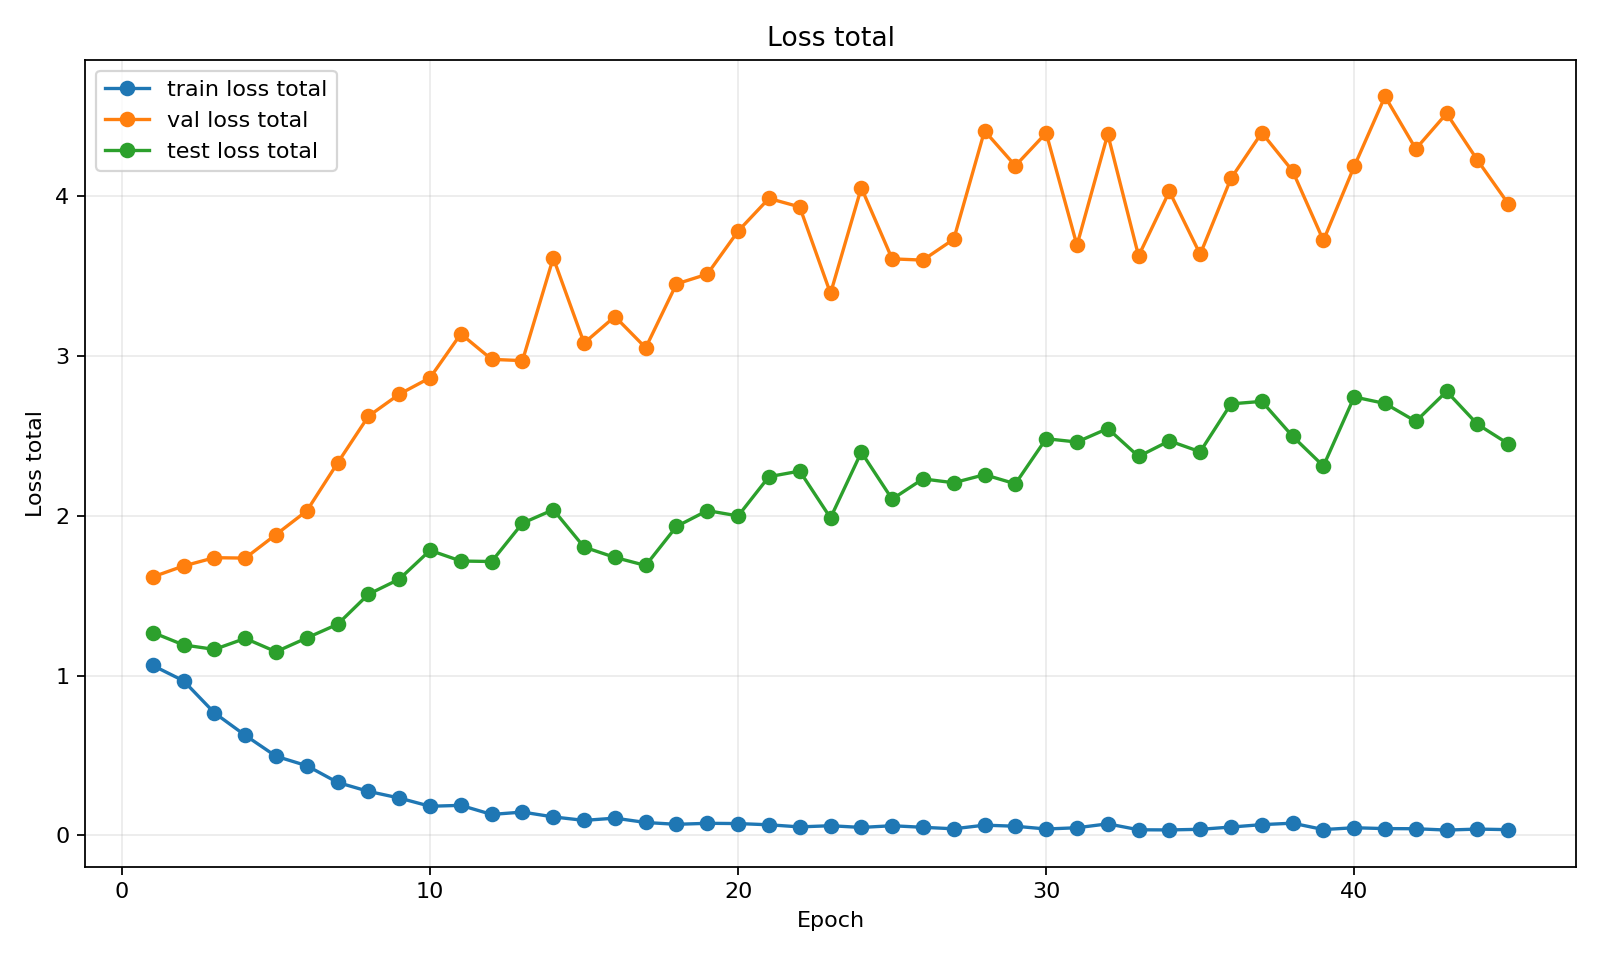

**Interpretacion.** La perdida de train cae casi a cero, mientras validacion y test suben con los epochs. Esto evidencia sobreajuste del reentrenamiento instrumentado; no invalida el entregable, pero justifica reportar el mejor checkpoint del sweep como KPI principal.

### 02_loss_infonce_por_epoch.png

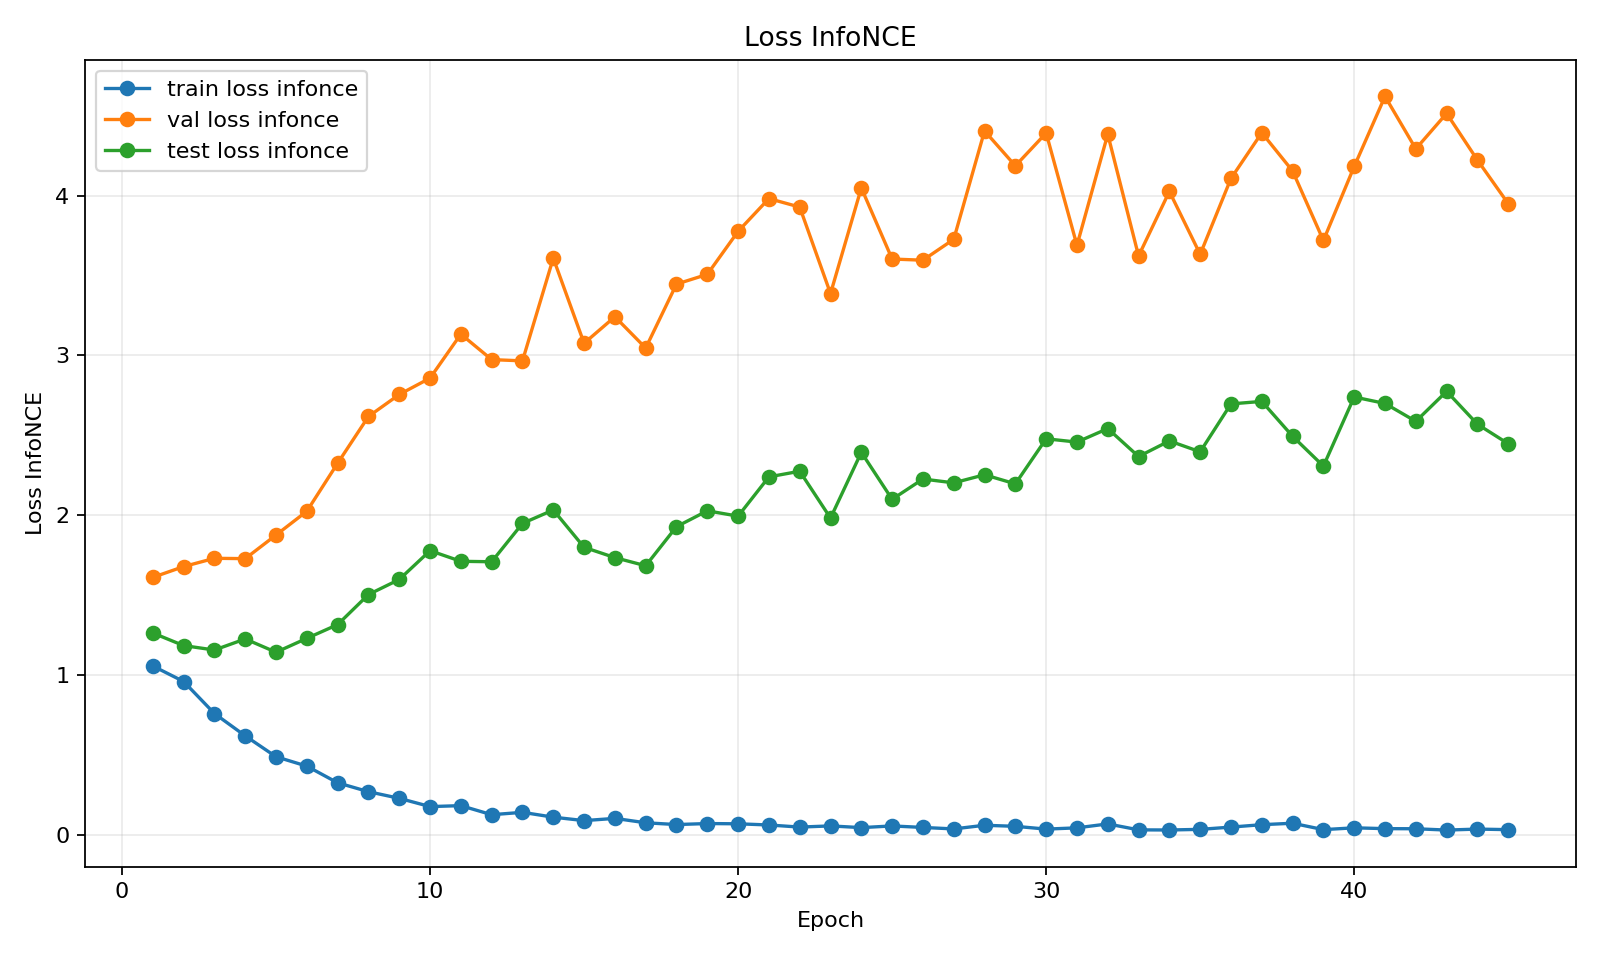

**Interpretacion.** Replica el patron del loss total porque InfoNCE domina la funcion objetivo. El modelo aprende fuertemente el alineamiento en train, pero la brecha con validacion/test muestra generalizacion limitada.

### 03_loss_sae_recon_por_epoch.png

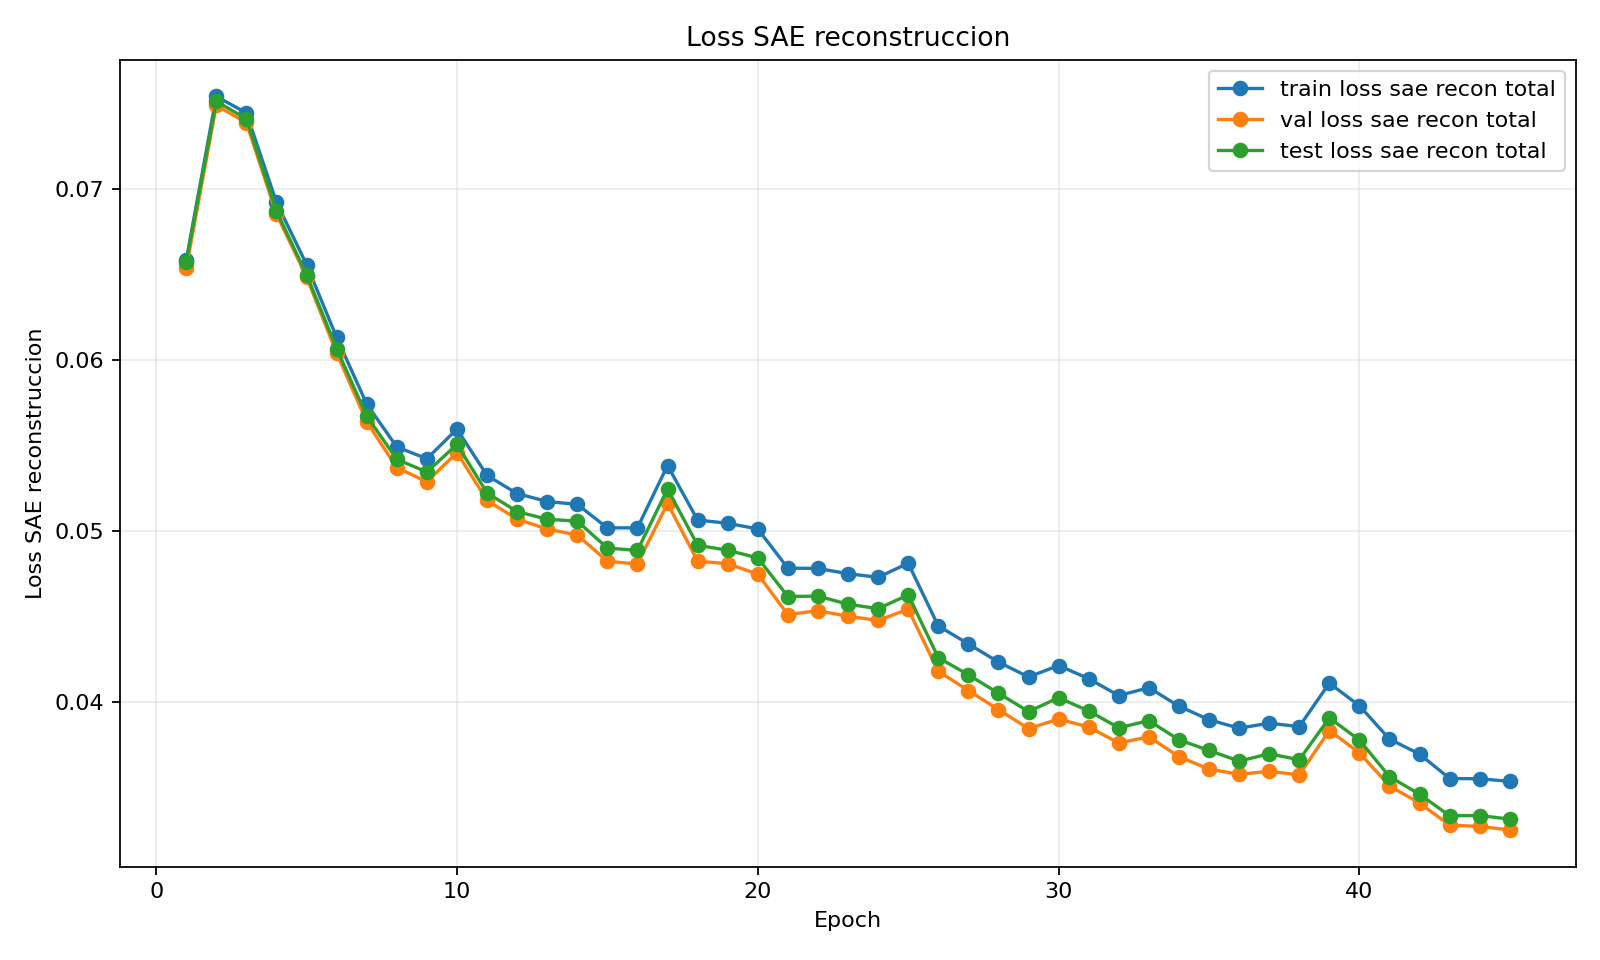

**Interpretacion.** El loss total de reconstruccion SAE baja de forma consistente en los tres splits, indicando que el autoencoder aprende a reconstruir la representacion latente sin colapso.

### 04_loss_sparsity_l1_por_epoch.png

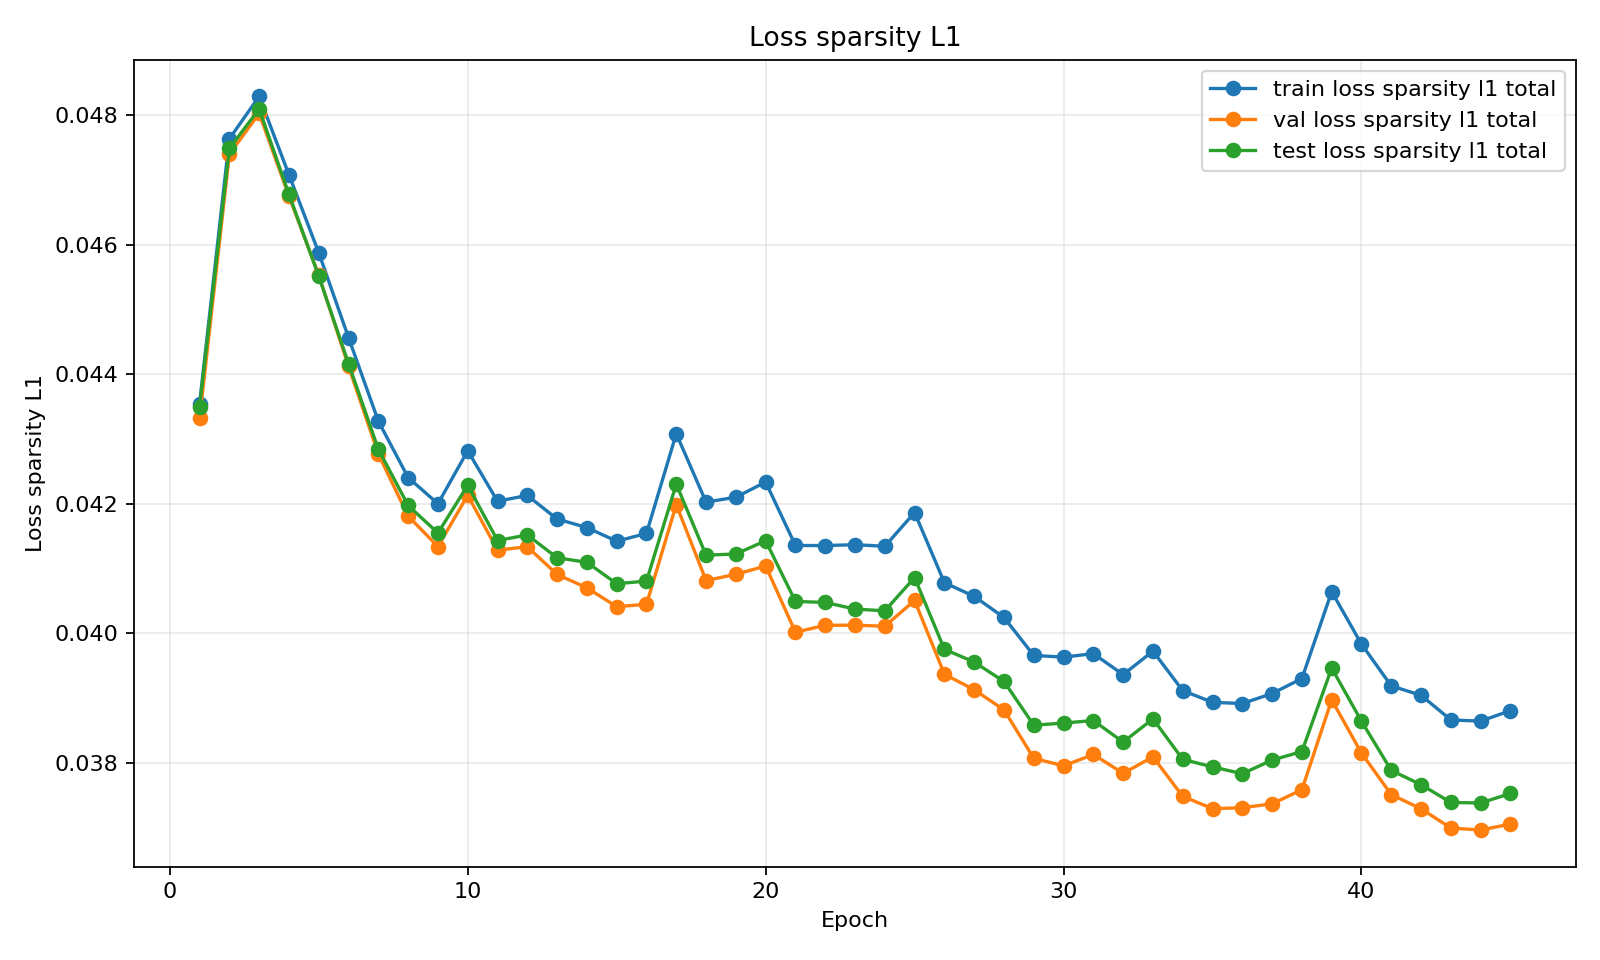

**Interpretacion.** La penalizacion L1 desciende gradualmente, coherente con activaciones mas compactas y controladas.

### 05_sparsity_por_epoch.png

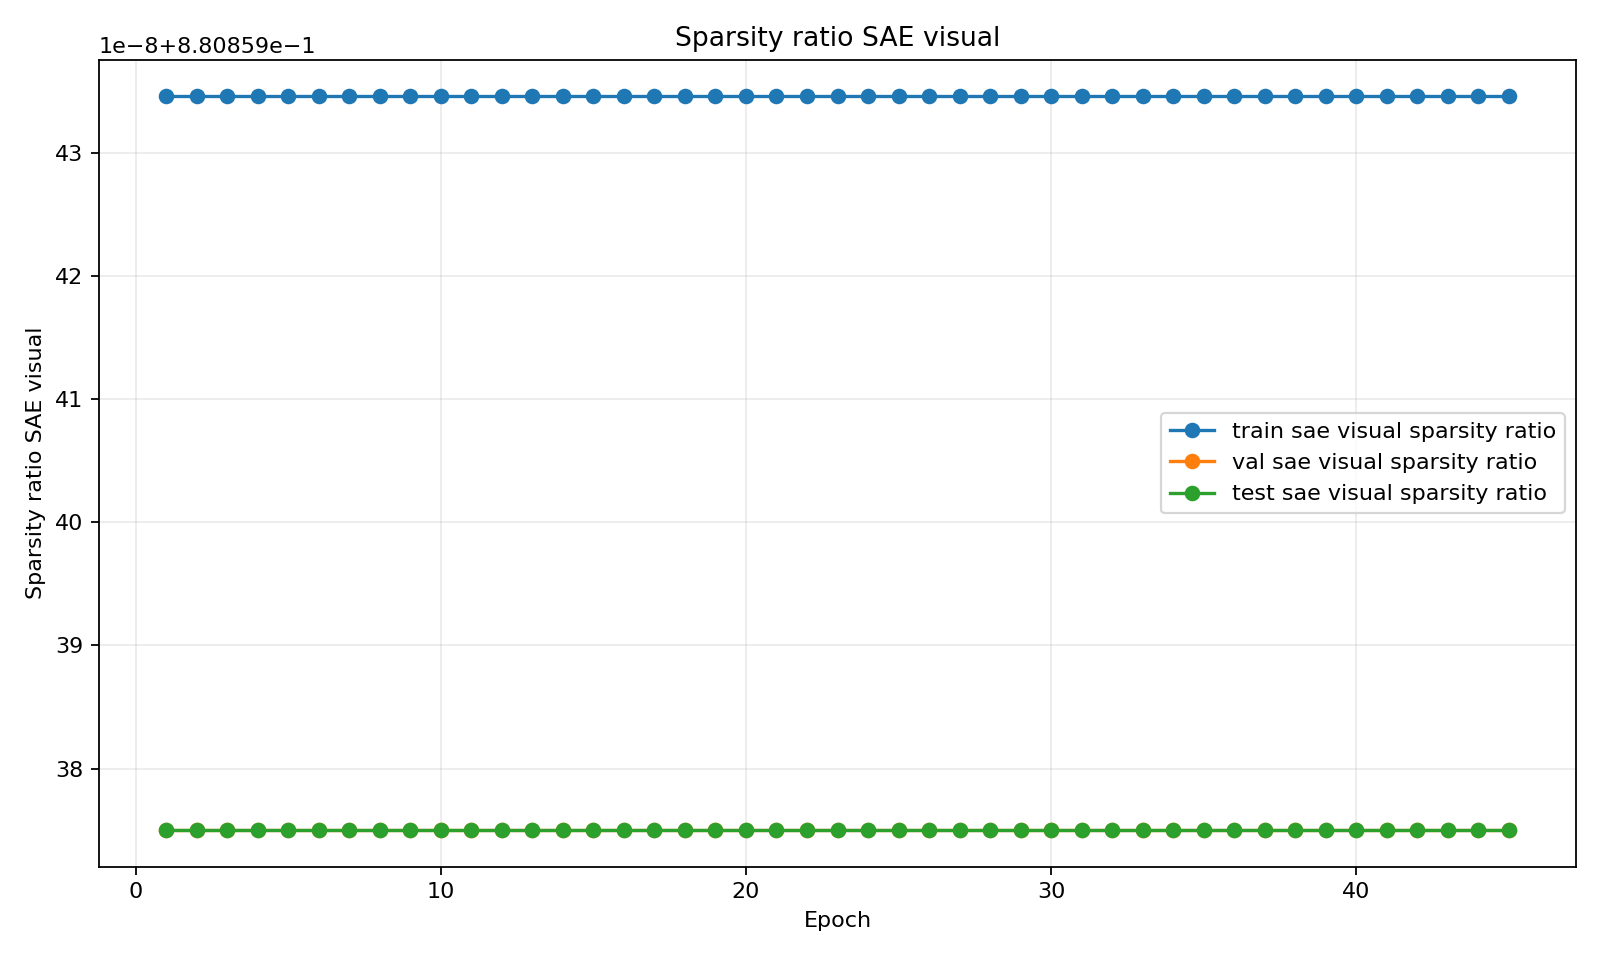

**Interpretacion.** La sparsity se mantiene practicamente constante alrededor de 0.8809; la figura usa offset numerico en el eje, por eso visualmente parece separada por niveles, pero el valor real permanece estable.

### 06_recon_mse_por_epoch.png

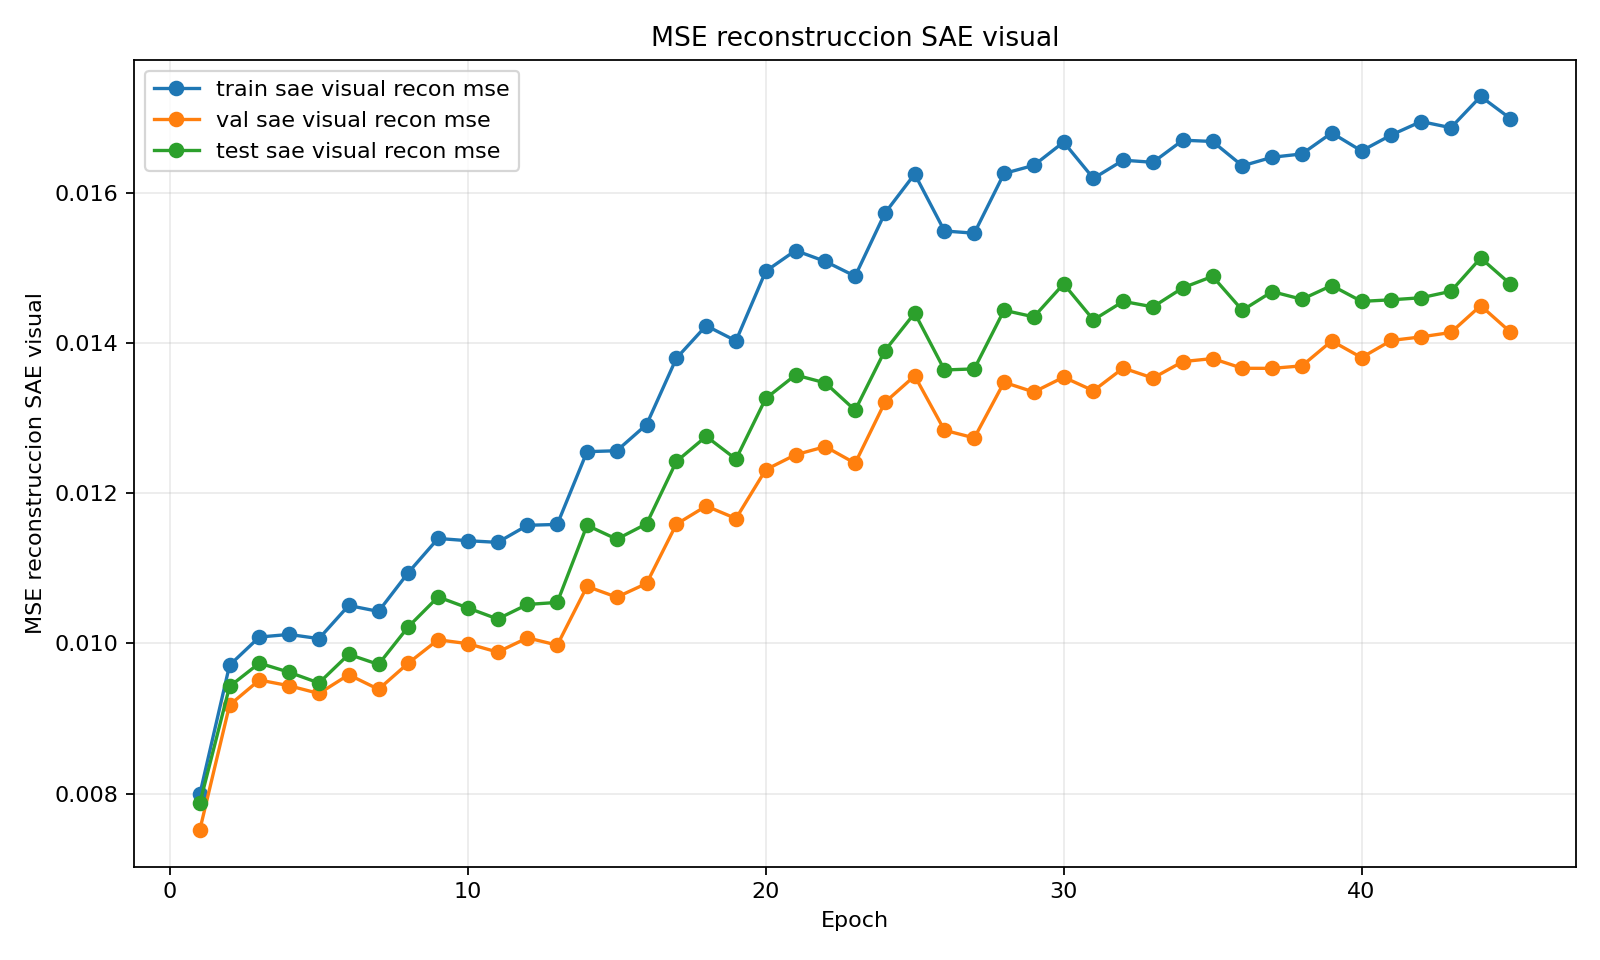

**Interpretacion.** El MSE visual aumenta moderadamente con los epochs, especialmente en train, pero se mantiene bajo y dentro del umbral excelente en el checkpoint principal reportado.

### 07_recall_por_epoch.png

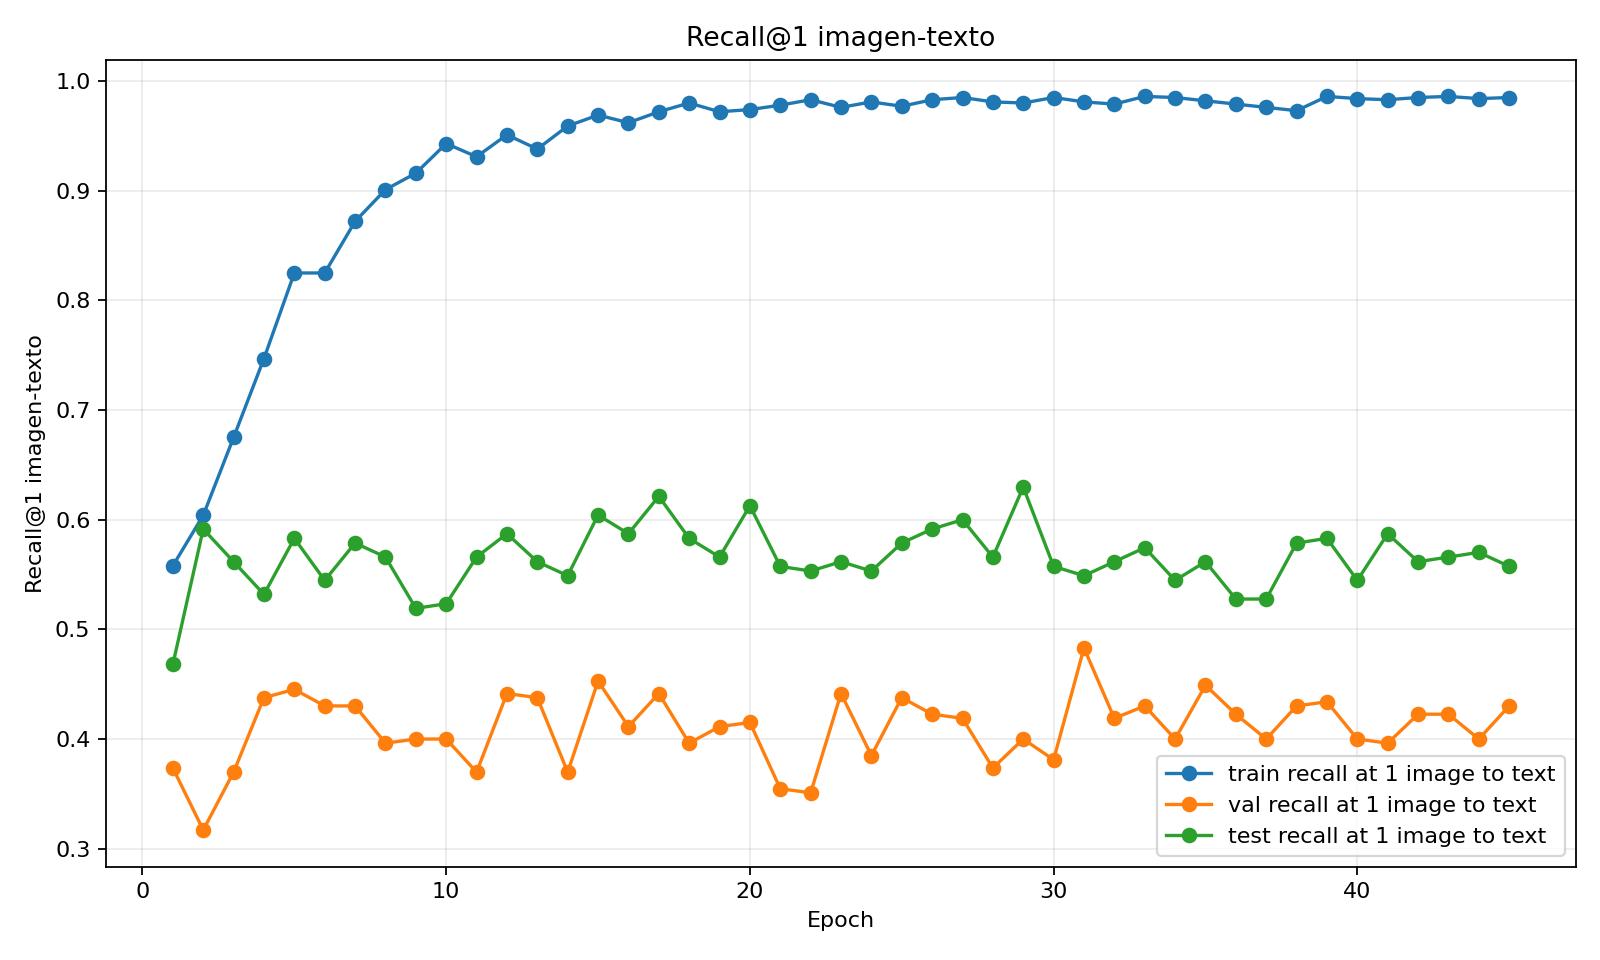

**Interpretacion.** Train sube hasta casi 1.0, mientras validacion oscila alrededor de 0.35-0.48 y test alrededor de 0.53-0.63. Esta brecha confirma sobreajuste parcial y apoya seleccionar por sweep/checkpoint, no por ultimo epoch.

In [3]:
interpretaciones = {
    '01_loss_total_por_epoch.png': 'La perdida de train cae casi a cero, mientras validacion y test suben con los epochs. Esto evidencia sobreajuste del reentrenamiento instrumentado; no invalida el entregable, pero justifica reportar el mejor checkpoint del sweep como KPI principal.',
    '02_loss_infonce_por_epoch.png': 'Replica el patron del loss total porque InfoNCE domina la funcion objetivo. El modelo aprende fuertemente el alineamiento en train, pero la brecha con validacion/test muestra generalizacion limitada.',
    '03_loss_sae_recon_por_epoch.png': 'El loss total de reconstruccion SAE baja de forma consistente en los tres splits, indicando que el autoencoder aprende a reconstruir la representacion latente sin colapso.',
    '04_loss_sparsity_l1_por_epoch.png': 'La penalizacion L1 desciende gradualmente, coherente con activaciones mas compactas y controladas.',
    '05_sparsity_por_epoch.png': 'La sparsity se mantiene practicamente constante alrededor de 0.8809; la figura usa offset numerico en el eje, por eso visualmente parece separada por niveles, pero el valor real permanece estable.',
    '06_recon_mse_por_epoch.png': 'El MSE visual aumenta moderadamente con los epochs, especialmente en train, pero se mantiene bajo y dentro del umbral excelente en el checkpoint principal reportado.',
    '07_recall_por_epoch.png': 'Train sube hasta casi 1.0, mientras validacion oscila alrededor de 0.35-0.48 y test alrededor de 0.53-0.63. Esta brecha confirma sobreajuste parcial y apoya seleccionar por sweep/checkpoint, no por ultimo epoch.',
}

for fig in sorted((ROOT / 'curvas').glob('*.png')):
    display(Markdown(f'### {fig.name}'))
    display(Image(filename=str(fig)))
    display(Markdown('**Interpretacion.** ' + interpretaciones.get(fig.name, 'Figura de control del entrenamiento.')))


In [4]:
with open(ROOT / 'metricas/full_logging_manifest.json') as f:
    manifest = json.load(f)
rows = []
for split, vals in manifest['final_metrics'].items():
    rows.append({
        'split': split,
        'recall_at_1': vals['recall_at_1_image_to_text'],
        'macro_recall': vals['macro_recall'],
        'sparsity_ratio': vals['sae_visual_sparsity_ratio'],
        'recon_mse': vals['sae_visual_recon_mse'],
    })
display(pd.DataFrame(rows))


,split,recall_at_1,macro_recall,sparsity_ratio,recon_mse
0,train,0.981000,0.980846,0.880859,0.016192
1,val,0.483019,0.469614,0.880859,0.013364
2,test,0.548936,0.550672,0.880859,0.014307


## Lectura Final

El reentrenamiento instrumentado alcanza `Recall@1 test = 0.5489` y aporta la evidencia temporal completa exigida por la rubrica. Las curvas muestran una tension clara: el retrieval contrastivo sobreajusta, pero el SAE conserva sparsity estable y reconstruccion dentro de niveles aceptables. La brecha train-test se reporta de forma transparente; el mejor checkpoint del sweep se usa como KPI principal porque fue seleccionado mediante comparacion sistematica de configuraciones y alcanza `Recall@1 test = 0.6043`.